In [1]:
pip install transformers datasets torch scikit-learn gradio matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset

# Load the smaller AG News dataset
dataset = load_dataset("HuyAugie/Smaller_AG_News_Dataset")

print(dataset)
print(dataset['train'][0])

# AG News has 4 classes:
# 0 = World, 1 = Sports, 2 = Business, 3 = Sci/Tech
label_names = ["World", "Sports", "Business", "Sci/Tech"]

ag_news_train_balanced.parquet:   0%|          | 0.00/651k [00:00<?, ?B/s]

ag_news_train_imbalanced.parquet:   0%|          | 0.00/313k [00:00<?, ?B/s]

ag_news_test_small.parquet:   0%|          | 0.00/650k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5900 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 5900
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 4000
    })
})
{'text': 'Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.', 'label': 0, '__index_level_0__': 8897}


In [3]:
print(dataset['train'][0])

{'text': 'Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.', 'label': 0, '__index_level_0__': 8897}


In [4]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128       # 128 is enough for short headlines
    )

# Apply tokenization to all splits
tokenized = dataset.map(tokenize, batched=True)

# Rename label column so PyTorch recognizes it
tokenized = tokenized.rename_column("label", "labels")

# Set format to PyTorch tensors
tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(tokenized['train'][0])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5900 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'labels': tensor(0), 'input_ids': tensor([  101,  7738,  5749, 13952,  5101, 13952,  1010,  5712,  1010,  2257,
         2484,  1011,  1011,  1037,  2482,  5968,  9913,  2379,  1996,  4796,
         1997,  1037,  2149,  1011,  6787,  8956,  2547,  2897,  1999, 13952,
         2006,  9857,  1010,  4288,  2012,  2560,  2048,  2111,  1998, 27285,
         2048,  2500,  1010,  4614,  1998,  9390,  2056,  1012,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

In [5]:
from torch.utils.data import DataLoader

# Step 1 — Dataset load karo
dataset = load_dataset("HuyAugie/Smaller_AG_News_Dataset")
print(dataset)  # pehle splits dekho

# Step 2 — Tokenize karo
tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Step 3 — Validation split manually banao
train_val    = tokenized["train"].train_test_split(test_size=0.1, seed=42)
train_loader = DataLoader(train_val["train"], batch_size=16, shuffle=True)
val_loader   = DataLoader(train_val["test"],  batch_size=32)
test_loader  = DataLoader(tokenized["test"],  batch_size=32)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 5900
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 4000
    })
})


In [6]:
import torch
from transformers import BertForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = BertForSequenceClassification.from_pretrained(
    "huawei-noah/TinyBERT_General_4L_312D",
    num_labels=4           # 4 AG News categories
)
model.to(device)

Using device: cuda


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

In [7]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score

EPOCHS = 3
LR     = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# ---- yeh naya function add hua hai ----
def evaluate_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_loss += outputs.loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


# ---- yeh training loop update hua hai ----
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc = evaluate_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val Acc    : {val_acc:.4f}")
    print()

Epoch 1/3
  Train Loss : 0.9691
  Val Loss   : 0.6429
  Val Acc    : 0.8288

Epoch 2/3
  Train Loss : 0.4917
  Val Loss   : 0.4199
  Val Acc    : 0.8780

Epoch 3/3
  Train Loss : 0.3704
  Val Loss   : 0.3666
  Val Acc    : 0.8949



  Accuracy : 0.8822
  F1 Score : 0.8820

              precision    recall  f1-score   support

       World       0.90      0.89      0.89      1000
      Sports       0.95      0.96      0.95      1000
    Business       0.84      0.80      0.82      1000
    Sci/Tech       0.84      0.88      0.86      1000

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



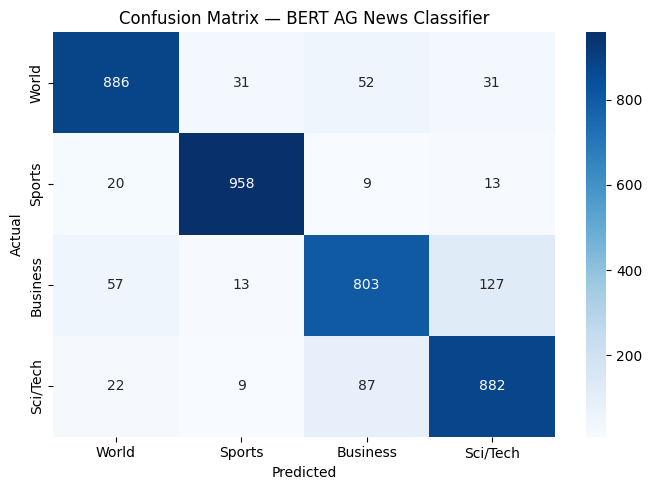

In [8]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Label names
label_names = ["World", "Sports", "Business", "Sci/Tech"]

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


# Test set pe final evaluation
y_true, y_pred = evaluate(model, test_loader, device)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average="weighted")

print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print("=" * 40)
print()
print(classification_report(y_true, y_pred, target_names=label_names))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — BERT AG News Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [9]:
import os

# Folder banao
os.makedirs("./bert_ag_news", exist_ok=True)

# Model aur tokenizer save karo
model.save_pretrained("./bert_ag_news")
tokenizer.save_pretrained("./bert_ag_news")

print("✅ Model saved!")
print("\nSaved files:")
for f in os.listdir("./bert_ag_news"):
    print(f"  {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!

Saved files:
  config.json
  tokenizer_config.json
  tokenizer.json
  model.safetensors


In [12]:
import shutil
from IPython.display import FileLink

# Zip banao
shutil.make_archive("/kaggle/working/bert_ag_news", "zip", "/kaggle/working/bert_ag_news")
print("✅ Zip ready!")

# Download link
FileLink('/kaggle/working/bert_ag_news.zip')

✅ Zip ready!


/kaggle/working/bert_ag_news.zip

In [13]:
from kaggle_secrets import UserSecretsClient
print("https://www.kaggle.com/code/mabdullahkhan999/notebook9d17ec24dd/edit")
print(os.getcwd())

# Apna notebook name dekho
import subprocess
result = subprocess.run(['kaggle', 'kernels', 'output', 'Abdullah Khan/News Topic Classifier Using BERT', '-p', '/kaggle/working'], 
                      capture_output=True, text=True)
print(result.stdout)

https://www.kaggle.com/code/mabdullahkhan999/notebook9d17ec24dd/edit
/kaggle/working
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/kernels.KernelsApiService/ListKernelSessionOutput

